In [1]:
import numpy as np
import pandas as pd
import math
import statsmodels.api as sm
from patsy import bs
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({"font.size": 16})       

In [2]:
df = pd.read_csv('../feature_extraction/new_math_df.csv')

In [3]:
df.columns

Index(['tutor', 'conversation_id', 'student_mistake', 'tutors_response',
       'PressReasoning_prob', 'PressAccuracy_prob', 'Uptake_prob',
       'politeness_score', 'agency_score', 'flesch_reading_ease', 'mtld',
       'word_count', 'flesch_score', 'flesch_ease', 'Mistake_Identification',
       'Mistake_Location', 'Actionability', 'Providing_Guidance'],
      dtype='object')

In [4]:
df['pedagogy_score'] = df.Mistake_Identification + df.Mistake_Location + df.Actionability + df.Providing_Guidance

In [5]:
mtld_na = df[df.mtld.isna()].conversation_id.tolist()

In [6]:
df = df[~df.conversation_id.isin(mtld_na)]

In [7]:
df["mtld_log"] = np.log1p(df["mtld"])
df["word_count_log"] = np.log1p(df["word_count"])

In [8]:
df.tutor.unique()

array(['Sonnet', 'Llama318B', 'Llama31405B', 'GPT4', 'Mistral', 'Expert',
       'Gemini', 'Phi3', 'Novice'], dtype=object)

In [9]:
features = [
    "PressReasoning_prob",
    "PressAccuracy_prob",
    "Uptake_prob",
    "word_count_log",
    "mtld_log",
    "flesch_reading_ease",
    "politeness_score",
    "agency_score",
]

feature_labels = {
    "PressReasoning_prob": "Pressing for reasoning",
    "PressAccuracy_prob": "Pressing for accuracy",
     "Uptake_prob": "Restating/Revoicing",
    "word_count_log": "Response length (log transformed)",
    "mtld_log": "Lexical diversity (MTLD)",
    "flesch_reading_ease": "Readability",
    "politeness_score": "Politeness",
    "agency_score": "Agency",
}

In [10]:
expert_tutor = "Expert"   # set to your exact label
novice_tutor = "Novice"   # set to your exact label

# Optional: order tutors with humans first, then LLMs alphabetical
tutors = list(df["tutor"].unique())
llms = sorted([t for t in tutors if t not in {expert_tutor, novice_tutor}])
tutor_order = [expert_tutor, novice_tutor] + llms

# If your labels differ or expert/novice are missing from the data, filter safely:
tutor_order = [t for t in tutor_order if t in tutors]

def paired_diff_stats(x, y):
    d = (x - y).dropna()
    n = len(d)
    mean = d.mean()
    se = d.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan
    # ci = 1.96 * se
    ci = stats.t.ppf(0.975, df=n-1) * se if n > 1 else np.nan
    return mean, ci, n

wide = {}
for f in features:
    wide[f] = df.pivot_table(
        index="conversation_id",
        columns="tutor",
        values=f,
        aggfunc="mean"
    )

rows = []
for f in features:
    for llm in llms:
        if llm not in wide[f].columns:
            continue
        m, ci, n = paired_diff_stats(wide[f][llm], wide[f]['Expert'])
        rows.append({
            "feature": f,
            "llm": llm,
            "mean_diff": m,
            "ci": ci,
            "n_turns": n
        })

diff_df = pd.DataFrame(rows)
novice = "Novice"        # your exact label
expert = "Expert"        # your exact label
NOV_LABEL = "Novice (ref)"

rows_nov = []
for f in features:
    w = wide[f]
    if novice not in w.columns or expert not in w.columns:
        continue

    # Overlap subset: turns where BOTH novice and expert have values
    mask = w[novice].notna() & w[expert].notna()
    if mask.sum() < 5:   # you can set a threshold (e.g., 10) if you prefer
        continue

    m, ci, n = paired_diff_stats(w.loc[mask, novice], w.loc[mask, expert])
    rows_nov.append({
        "feature": f,
        "llm": NOV_LABEL,     # reuse the plotting column
        "mean_diff": m,
        "ci": ci,
        "n_turns": n,
        "is_novice_ref": True
    })

nov_df = pd.DataFrame(rows_nov)

# Ensure your existing diff_df has this flag too
diff_df = diff_df.copy()
diff_df["is_novice_ref"] = False

diff_df2 = pd.concat([diff_df, nov_df], ignore_index=True)

In [11]:
test_rows = []

for f in features:
    w = wide[f]

    # LLMs vs Expert
    for llm in llms:
        if llm not in w.columns or expert not in w.columns:
            continue

        d = (w[llm] - w[expert]).dropna()

        if len(d) >= 2:
            t, p = stats.ttest_1samp(d, popmean=0)
        else:
            t, p = np.nan, np.nan

        test_rows.append({
            "feature": f,
            "llm": llm,
            "n": len(d),
            "t": t,
            "p": p
        })

    # Novice vs Expert
    if novice in w.columns and expert in w.columns:
        d = (w[novice] - w[expert]).dropna()

        if len(d) >= 2:
            t, p = stats.ttest_1samp(d, popmean=0)
        else:
            t, p = np.nan, np.nan

        test_rows.append({
            "feature": f,
            "llm": NOV_LABEL,
            "n": len(d),
            "t": t,
            "p": p
        })

test_df = pd.DataFrame(test_rows)

valid = test_df["p"].notna()

test_df.loc[valid, "p_fdr"] = multipletests(
    test_df.loc[valid, "p"],
    method="fdr_bh"
)[1]

def sig_label(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

test_df["sig_fdr"] = test_df["p_fdr"].apply(sig_label)

# Figure 1

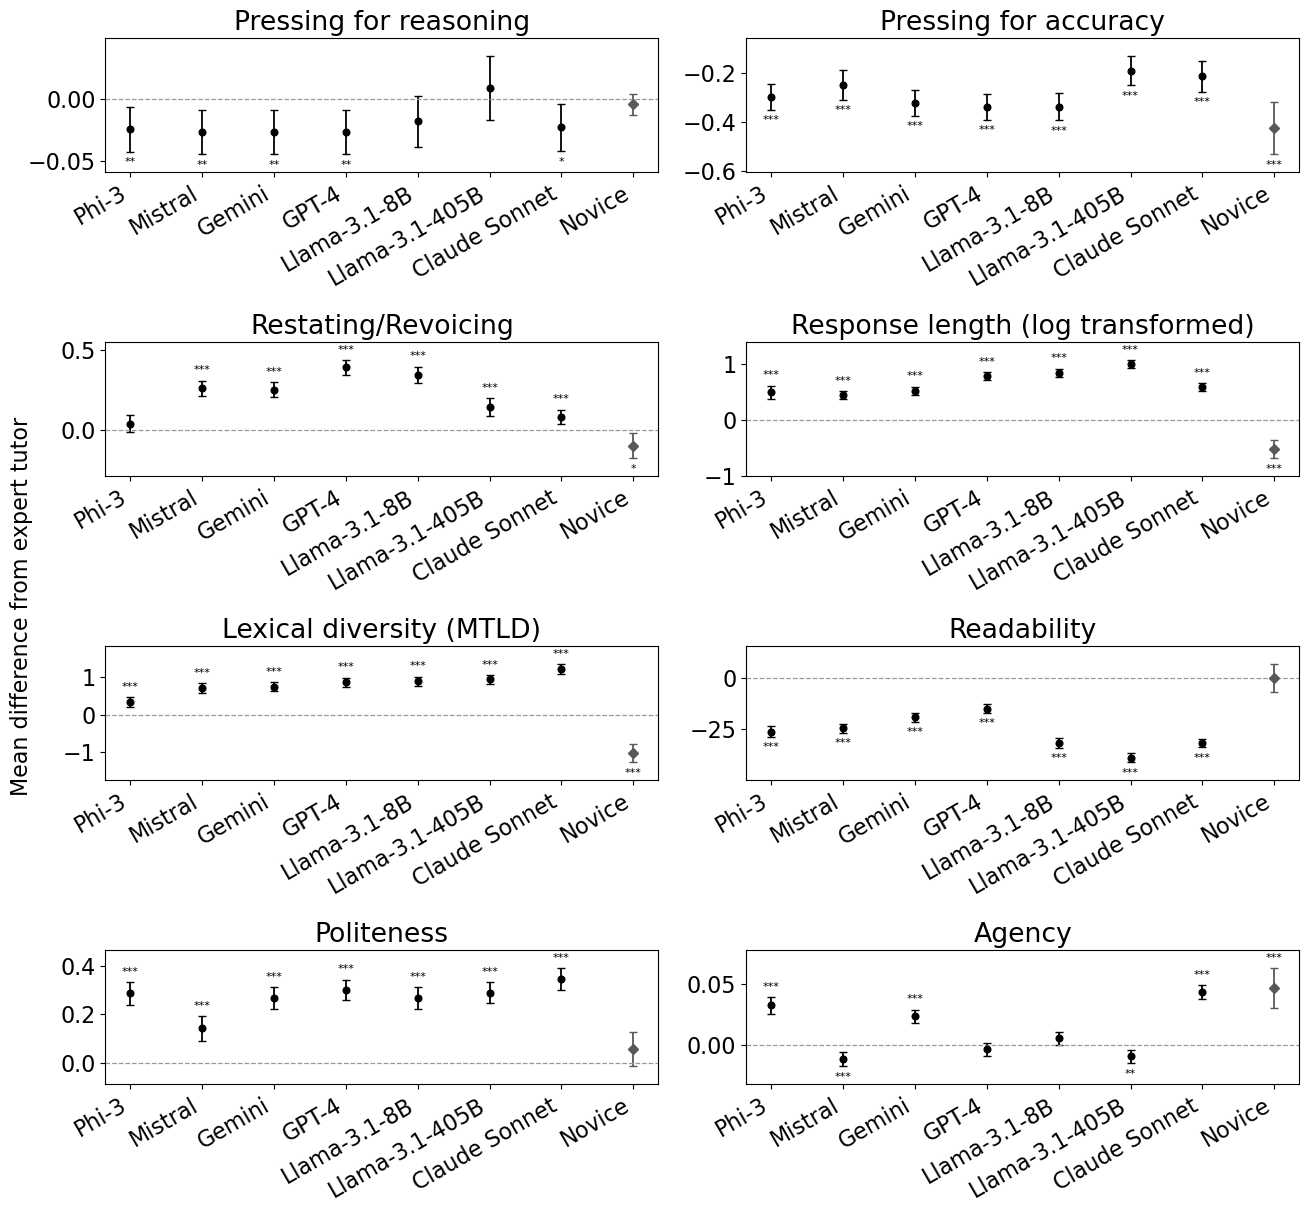

In [12]:
n_feats = len(features)
ncols = 2
nrows = math.ceil(n_feats / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(13.2, 3.1 * nrows), sharex=False)
axes = np.array(axes).reshape(nrows, ncols)

# name mapping
name_map = {
    "GPT4": "GPT-4",
    "Gemini": "Gemini",
    "Mistral": "Mistral",
    "Phi3": "Phi-3",
    "Sonnet": "Claude Sonnet",
    "Llama31405B": "Llama-3.1-405B",
    "Llama318B": "Llama-3.1-8B",
    "Novice (ref)": "Novice",
}

# tutor order
model_order = [
    "Phi3", "Mistral", "Gemini", "GPT4", "Llama318B", "Llama31405B", "Sonnet", "Novice"
]

# Helper for ordering
def order_key(x):
    try:
        return model_order.index(x)
    except ValueError:
        return 999

for i, f in enumerate(features):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    sub = diff_df2[diff_df2["feature"] == f].copy()
    # ---------------
    sub = sub.merge(
    test_df[["feature", "llm", "p", "p_fdr", "sig_fdr"]],
    on=["feature", "llm"],
    how="left"
)
    # ---------------

    # Ensure we have novice row flagged correctly; keep novice last
    sub["order"] = sub["llm"].apply(order_key)
    sub = sub.sort_values("order")

    # Map display names
    sub["label"] = sub["llm"].map(name_map).fillna(sub["llm"])

    # X positions
    x = np.arange(len(sub))
    y = sub["mean_diff"].to_numpy()
    yerr = sub["ci"].to_numpy()
    is_nov = sub["is_novice_ref"].to_numpy()

    # LLMs: neutral markers (single color)
    ax.errorbar(
        x[~is_nov], y[~is_nov], yerr=yerr[~is_nov],
        fmt="o", capsize=3.2, elinewidth=1.3, markersize=4.8, color="black"
    )
    # --------------
    # Add FDR-corrected significance stars, with padding inside axis limits
    y_low = np.nanmin(y - yerr)
    y_high = np.nanmax(y + yerr)
    y_span = y_high - y_low if y_high > y_low else 1
    
    pad = 0.18 * y_span
    ax.set_ylim(y_low - pad, y_high + pad)
    
    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin
    
    for xi, yi, ei, sig in zip(x, y, yerr, sub["sig_fdr"]):
        if sig:
            if yi >= 0:
                ypos = yi + ei + 0.04 * yrange
                va = "bottom"
            else:
                ypos = yi - ei - 0.04 * yrange
                va = "top"
    
            # keep stars inside panel
            ypos = min(max(ypos, ymin + 0.06 * yrange), ymax - 0.06 * yrange)
    
            ax.text(
                xi, ypos, sig,
                ha="center",
                va=va,
                fontsize=8,
                color="black",
                clip_on=False
            )
    # --------------

    # Novice reference: gray diamond (no “special color” beyond gray)
    if is_nov.any():
        ax.errorbar(
            x[is_nov], y[is_nov], yerr=yerr[is_nov],
            fmt="D", capsize=3.2, elinewidth=1.3, markersize=5.2,
            color="0.35"
        )

    # Lighter zero line (since repeated in every panel)
    ax.axhline(0, linestyle="--", color="0.6", linewidth=0.9)

    # Titles: keep short
    ax.set_title(f"{feature_labels[f]}")#(Tutor − Expert)

    # X ticks: set labels, but show only on bottom row to reduce clutter
    ax.set_xticks(x)
    ax.set_xticklabels(sub["label"].tolist(), rotation=30, ha="right")

    # Determine last occupied row for each column
    last_row_per_col = {}
    for idx in range(n_feats):
        rr, cc = divmod(idx, ncols)
        last_row_per_col[cc] = max(last_row_per_col.get(cc, -1), rr)
    
    # Hide x labels except for the last occupied row in each column
    # if r != last_row_per_col[c]:
    #     ax.set_xticklabels([])


    # Remove per-axis y label; will add one global label
    ax.set_ylabel("")

    # Lighten frame
    # ax.spines["top"].set_visible(False)
    # ax.spines["right"].set_visible(False)

# Hide unused panels
for j in range(n_feats, nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis("off")

# Global y-label and title
fig.text(0.005, 0.5, "Mean difference from expert tutor", va="center", rotation="vertical")
# fig.suptitle("Instructional and linguistic profiles relative to expert (raw-scale differences)", y=1.01, fontsize=14)

fig.tight_layout()
plt.savefig('plots/feature_plot_realtivetoexpert.pdf', dpi=300, bbox_inches="tight")
plt.show()

# Figure 2

In [13]:
dims = ["Mistake_Identification", "Mistake_Location", "Actionability", "Providing_Guidance"]
y_col = "pedagogy_score"
id_col = "conversation_id"
tutor_col = "tutor"
d = df[[id_col, y_col, tutor_col] + features + dims].dropna().copy()
d["pedagogy_within"] = d[y_col] - d.groupby(id_col)[y_col].transform("mean")

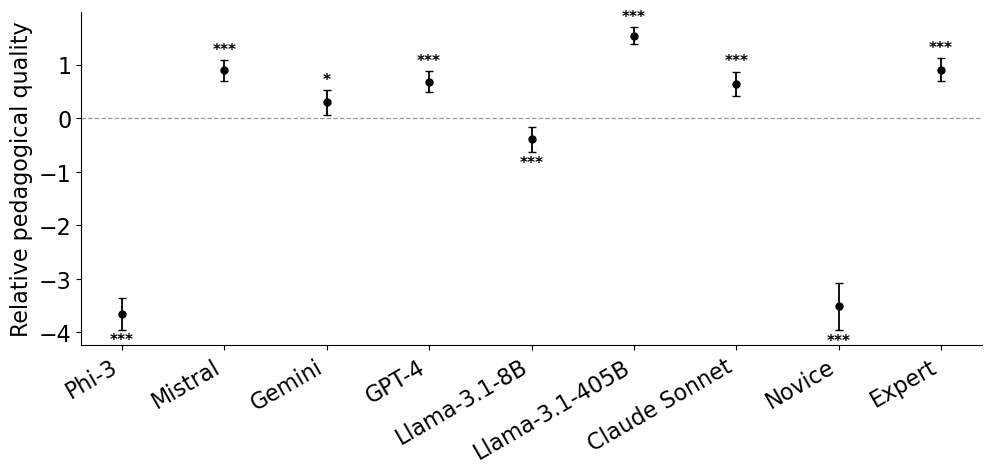

'note: * p < .05, ** p < .01, *** p < .001 after Benjamini–Hochberg FDR correction.'

In [14]:
# with asteriks
# from scipy import stats
# from statsmodels.stats.multitest import multipletests

def se_mean(x):
    n = len(x)
    if n <= 1:
        return np.nan
    return x.std(ddof=1) / np.sqrt(n)

def sig_label(p):
    if pd.isna(p):
        return ""
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

stats_df = (
    d.groupby(tutor_col)["pedagogy_within"]
     .agg(mean="mean", se=se_mean, n="size")
     .reset_index()
)

# one-sample t-tests against 0
test_df = (
    d.groupby(tutor_col)["pedagogy_within"]
     .apply(lambda x: stats.ttest_1samp(x.dropna(), popmean=0).pvalue if x.dropna().shape[0] >= 2 else np.nan)
     .reset_index(name="p")
)

valid = test_df["p"].notna()
test_df["p_fdr"] = np.nan
test_df.loc[valid, "p_fdr"] = multipletests(
    test_df.loc[valid, "p"],
    method="fdr_bh"
)[1]

test_df["sig_fdr"] = test_df["p_fdr"].apply(sig_label)

stats_df = stats_df.merge(
    test_df[[tutor_col, "p", "p_fdr", "sig_fdr"]],
    on=tutor_col,
    how="left"
)

model_order = [
    "Phi3", "Mistral", "Gemini", "GPT4",
    "Llama318B", "Llama31405B", "Sonnet", "Novice"
]
tutor_order = model_order + ["Expert"]

stats_df["order"] = stats_df[tutor_col].apply(
    lambda t: tutor_order.index(t) if t in tutor_order else 999
)
stats_df = stats_df.sort_values("order")

stats_df["label"] = stats_df[tutor_col].map(name_map).fillna(stats_df[tutor_col])

x = np.arange(len(stats_df))

fig, ax = plt.subplots(figsize=(10.2, 5))

ci = 1.96 * stats_df["se"]

ax.errorbar(
    x,
    stats_df["mean"],
    yerr=ci,
    fmt="o",
    capsize=3.2,
    elinewidth=1.3,
    markersize=5,
    color="black"
)

# add FDR-corrected significance asterisks
y_range = (stats_df["mean"] + ci).max() - (stats_df["mean"] - ci).min()
offset = 0.01 * y_range

for i, row in stats_df.reset_index(drop=True).iterrows():
    sig = row["sig_fdr"]
    if sig == "":
        continue

    if row["mean"] >= 0:
        y = row["mean"] + 1.96 * row["se"] + offset
        va = "bottom"
    else:
        y = row["mean"] - 1.96 * row["se"] - offset
        va = "top"

    ax.text(
        i,
        y,
        sig,
        ha="center",
        va=va,
        fontsize=11,
        fontweight="bold"
    )

ax.axhline(0, color="0.6", linestyle="--", linewidth=0.9)

ax.set_xticks(x)
ax.set_xticklabels(stats_df["label"], rotation=30, ha="right")
ax.set_ylabel("Relative pedagogical quality")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("plots/relative_pedagogical_quality.pdf", dpi=300, bbox_inches="tight")
plt.show()
"note: * p < .05, ** p < .01, *** p < .001 after Benjamini–Hochberg FDR correction."

# Per dimension

In [15]:
for dim in dims:
    d[f"{dim}_within"] = d[dim] - d.groupby(id_col)[dim].transform("mean")

dim_stats = []

for dim in dims:
    y_col = f"{dim}_within"

    tmp = (
        d.groupby(tutor_col)[y_col]
         .agg(mean="mean", se=se_mean, n="size")
         .reset_index()
    )

    # one-sample t-tests against 0
    test_tmp = (
        d.groupby(tutor_col)[y_col]
         .apply(
             lambda x: stats.ttest_1samp(x.dropna(), popmean=0).pvalue
             if x.dropna().shape[0] >= 2 else np.nan
         )
         .reset_index(name="p")
    )

    valid = test_tmp["p"].notna()
    test_tmp["p_fdr"] = np.nan

    test_tmp.loc[valid, "p_fdr"] = multipletests(
        test_tmp.loc[valid, "p"],
        method="fdr_bh"
    )[1]

    test_tmp["sig_fdr"] = test_tmp["p_fdr"].apply(sig_label)

    tmp = tmp.merge(
        test_tmp[[tutor_col, "p", "p_fdr", "sig_fdr"]],
        on=tutor_col,
        how="left"
    )

    tmp["dimension"] = dim
    dim_stats.append(tmp)

dim_stats = pd.concat(dim_stats, ignore_index=True)

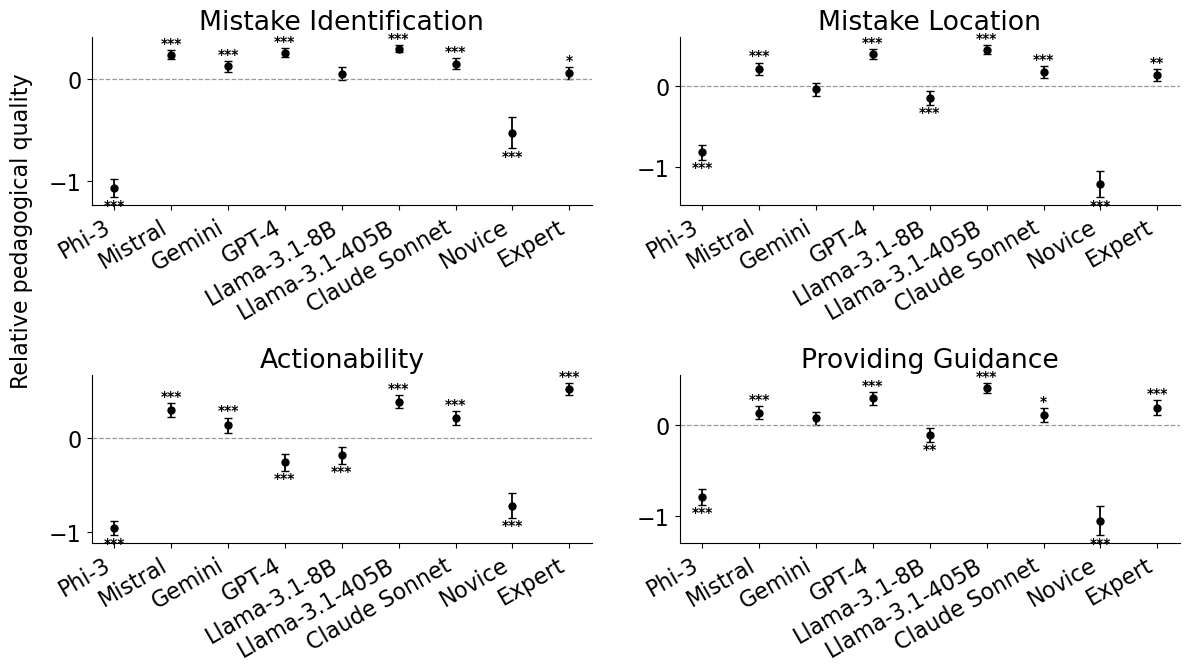

In [16]:
# with astreiks
ncols = 2
nrows = int(np.ceil(len(dims) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.5 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

for i, dim in enumerate(dims):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    sub = dim_stats[dim_stats["dimension"] == dim].copy()

    sub["order"] = sub[tutor_col].apply(
        lambda t: tutor_order.index(t) if t in tutor_order else 999
    )
    sub = sub.sort_values("order")

    sub["label"] = sub[tutor_col].map(name_map).fillna(sub[tutor_col])

    x = np.arange(len(sub))
    ci = 1.96 * sub["se"]

    ax.errorbar(
        x,
        sub["mean"],
        yerr=ci,
        fmt="o",
        capsize=3.2,
        elinewidth=1.3,
        markersize=5,
        color="black"
    )

    # significance labels
    y_range = (sub["mean"] + ci).max() - (sub["mean"] - ci).min()
    offset = 0.001 * y_range if y_range > 0 else 0.05

    for j, row in sub.reset_index(drop=True).iterrows():

        sig = row["sig_fdr"] if "sig_fdr" in row else row["sig"]

        if pd.isna(sig) or sig == "":
            continue

        if row["mean"] >= 0:
            y = row["mean"] + 1.96 * row["se"] + offset
            va = "bottom"
        else:
            y = row["mean"] - 1.96 * row["se"] - offset
            va = "top"

        ax.text(
            j,
            y,
            sig,
            ha="center",
            va=va,
            fontsize=10,
            fontweight="bold"
        )

    ax.axhline(0, color="0.6", linestyle="--", linewidth=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(sub["label"], rotation=30, ha="right")

    ax.set_title(dim.replace("_", " "))
    

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
# Global y-label and title
fig.text(0.005, 0.65, "Relative pedagogical quality", va="center", rotation="vertical")
fig.tight_layout()
plt.savefig("plots/relative_pedagogical_quality_dimensions.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
dim_stats["display"] = dim_stats.apply(
    lambda r: f"{r['mean']:.3f}{r['sig_fdr'] if pd.notna(r['sig_fdr']) else ''}",
    axis=1
)
table = dim_stats.pivot_table(
    index=tutor_col,
    columns="dimension",
    values="display",
    aggfunc="first"
)
print(table.round(3).to_markdown())

'''
Entries report mean within-turn deviations; 
stars indicate FDR-corrected significance levels (* p < .05, ** p < .01, *** p < .001).
'''

| tutor       | Actionability   | Mistake_Identification   | Mistake_Location   | Providing_Guidance   |
|:------------|:----------------|:-------------------------|:-------------------|:---------------------|
| Expert      | 0.527***        | 0.063*                   | 0.130**            | 0.185***             |
| GPT4        | -0.257***       | 0.262***                 | 0.387***           | 0.290***             |
| Gemini      | 0.142***        | 0.127***                 | -0.045             | 0.070                |
| Llama31405B | 0.392***        | 0.303***                 | 0.444***           | 0.401***             |
| Llama318B   | -0.182***       | 0.056                    | -0.157***          | -0.116**             |
| Mistral     | 0.308***        | 0.242***                 | 0.211***           | 0.131***             |
| Novice      | -0.718***       | -0.526***                | -1.218***          | -1.054***            |
| Phi3        | -0.963***       | -1.072***            

'\nEntries report mean within-turn deviations; \nstars indicate FDR-corrected significance levels (* p < .05, ** p < .01, *** p < .001).\n'

# Figure 3

In [18]:
dims

['Mistake_Identification',
 'Mistake_Location',
 'Actionability',
 'Providing_Guidance']

In [19]:
# 1. Within-error-turn demeaning
y_col = "pedagogy_score"
within = d.groupby(id_col)[[y_col] + features].transform("mean")
d_w = d[[y_col] + features] - within

# 2. Z-score predictors AFTER demeaning
X = d_w[features]
X = (X - X.mean()) / X.std()

y = d_w[y_col]

X_const = sm.add_constant(X)
m_const = sm.OLS(y, X_const).fit(
    cov_type="cluster",
    cov_kwds={"groups": d[id_col]}
)
with open("regression_table.tex", "w") as f:
    f.write(m_const.summary().as_latex())
print(m_const.summary())

                            OLS Regression Results                            
Dep. Variable:         pedagogy_score   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     110.4
Date:                Tue, 26 May 2026   Prob (F-statistic):           4.49e-84
Time:                        15:48:15   Log-Likelihood:                -5387.5
No. Observations:                2444   AIC:                         1.079e+04
Df Residuals:                    2435   BIC:                         1.085e+04
Df Model:                           8                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                5.204e-17   2

# aggregate pedagogical quality model

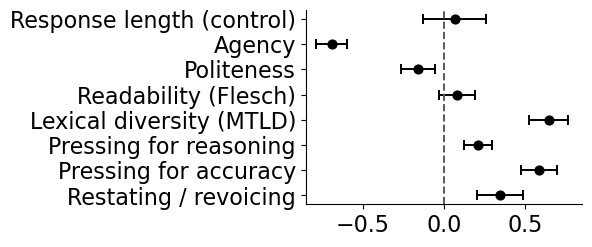

In [20]:
# Extract results
res = m_const  # OLS model with clustered SEs (by conversation turn)
coefs = res.params
ses = res.bse

coef_df = pd.DataFrame({
    "feature": coefs.index.astype(str),
    "coef": coefs.values,
    "se": ses.values
})

# Drop intercept/constant (common names across statsmodels specs)
drop_terms = {"const", "Intercept", "(Intercept)"}
coef_df = coef_df[~coef_df["feature"].isin(drop_terms)].copy()

# Compute 95% CI
z = 1.96
coef_df["ci_low"] = coef_df["coef"] - z * coef_df["se"]
coef_df["ci_high"] = coef_df["coef"] + z * coef_df["se"]

# map labels
label_map = {
    "Uptake_prob": "Restating / revoicing",
    "PressAccuracy_prob": "Pressing for accuracy",
    "PressReasoning_prob":"Pressing for reasoning",
    "mtld_log": "Lexical diversity (MTLD)",
    "flesch_reading_ease": "Readability (Flesch)",
    "politeness_score": "Politeness",
    "agency_score": "Agency",
    "word_count_log": "Response length (control)",    
}

coef_df["label"] = coef_df["feature"].map(label_map).fillna(coef_df["feature"])

# Conceptual ordering (instructional-linguistic-control)
desired_order = [
    "Restating / revoicing",
    "Pressing for accuracy",
    "Pressing for reasoning",
    "Lexical diversity (MTLD)",
    "Readability (Flesch)",
    "Politeness",
    "Agency",
    "Response length (control)",
]

# Keep labels in desired order
present = [x for x in desired_order if x in set(coef_df["label"])]
# Append other features if any
extras = [x for x in coef_df["label"].unique() if x not in present]
final_order = present + sorted(extras)

coef_df["label"] = pd.Categorical(coef_df["label"], categories=final_order, ordered=True)
coef_df = coef_df.sort_values("label")

# Plot
fig, ax = plt.subplots(figsize=(6.2, 2.75))

ax.errorbar(
    coef_df["coef"],
    coef_df["label"],
    xerr=z * coef_df["se"],
    fmt="o",
    markersize=5.5,
    elinewidth=1.4,
    capsize=3.5,
    capthick=1.4,
    color="black"  
)

# draw markers
ax.scatter(coef_df["coef"], coef_df["label"], c='black', s=40, zorder=3)

# Zero reference line
ax.axvline(0, color="0.35", linestyle="--", linewidth=1.4)

# symmetric x-limits for easier visual comparison
max_abs = np.max(np.abs(np.r_[coef_df["ci_low"].values, coef_df["ci_high"].values]))
pad = 0.08 * max_abs
ax.set_xlim(-(max_abs + pad), (max_abs + pad))

ax.set_xlabel("")
ax.set_ylabel("")
#ax.set_title("Instructional and linguistic features associated with perceived pedagogical quality")

# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("plots/coef_plot_pedagogical_quality.pdf", dpi=300, bbox_inches="tight")
plt.show()

# model per dimension

In [21]:
import statsmodels.api as sm
import pandas as pd

pedagogy_dims = dims
features = [
    "PressReasoning_prob",
    "PressAccuracy_prob",
    "Uptake_prob",
    "word_count_log",
    "mtld_log",
    "flesch_reading_ease",
    "politeness_score",
    "agency_score",
]

cols = pedagogy_dims + features

# 1. Within-transform outcomes and predictors
within = d.groupby(id_col)[cols].transform("mean")
d_w = d[cols] - within

# 2. Z-score predictors after demeaning
X = d_w[features]
X = (X - X.mean()) / X.std()

X_const = sm.add_constant(X)

models = {}

for y_col in pedagogy_dims:
    y = d_w[y_col]

    m = sm.OLS(y, X_const).fit(
        cov_type="cluster",
        cov_kwds={"groups": d[id_col]}
    )

    models[y_col] = m
    print("\n" + "=" * 80)
    print(f"Outcome: {y_col}")
    print(m.summary())


Outcome: Mistake_Identification
                              OLS Regression Results                              
Dep. Variable:     Mistake_Identification   R-squared:                       0.205
Model:                                OLS   Adj. R-squared:                  0.203
Method:                     Least Squares   F-statistic:                     59.95
Date:                    Tue, 26 May 2026   Prob (F-statistic):           1.93e-57
Time:                            15:48:15   Log-Likelihood:                -2189.1
No. Observations:                    2444   AIC:                             4396.
Df Residuals:                        2435   BIC:                             4448.
Df Model:                               8                                         
Covariance Type:                  cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------

# plot coefficient for each dimension

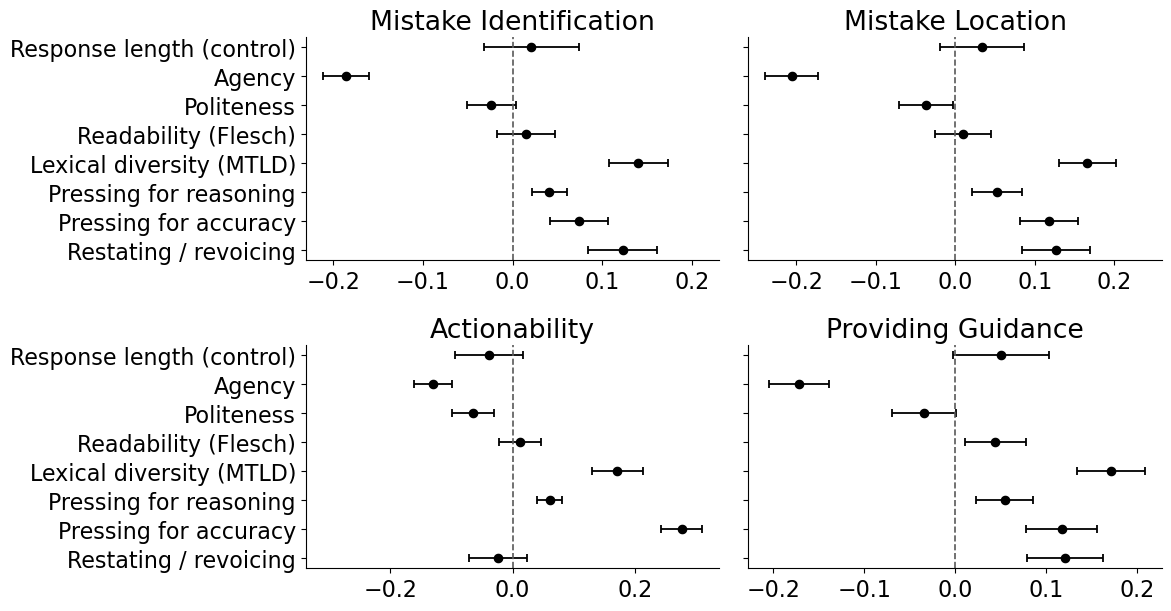

In [22]:
# Extract coefficients from per-dimension models
rows = []

for dim, res in models.items():
    coefs = res.params
    ses = res.bse

    tmp = pd.DataFrame({
        "dimension": dim,
        "feature": coefs.index.astype(str),
        "coef": coefs.values,
        "se": ses.values
    })

    rows.append(tmp)

coef_dim_df = pd.concat(rows, ignore_index=True)

# Drop intercept/constant
drop_terms = {"const", "Intercept", "(Intercept)"}
coef_dim_df = coef_dim_df[~coef_dim_df["feature"].isin(drop_terms)].copy()

# Compute 95% CI
z = 1.96
coef_dim_df["ci_low"] = coef_dim_df["coef"] - z * coef_dim_df["se"]
coef_dim_df["ci_high"] = coef_dim_df["coef"] + z * coef_dim_df["se"]

# Labels
label_map = {
    "Uptake_prob": "Restating / revoicing",
    "PressAccuracy_prob": "Pressing for accuracy",
    "PressReasoning_prob": "Pressing for reasoning",
    "mtld_log": "Lexical diversity (MTLD)",
    "flesch_reading_ease": "Readability (Flesch)",
    "politeness_score": "Politeness",
    "agency_score": "Agency",
    "word_count_log": "Response length (control)",
}

coef_dim_df["label"] = coef_dim_df["feature"].map(label_map).fillna(coef_dim_df["feature"])

desired_order = [
    "Restating / revoicing",
    "Pressing for accuracy",
    "Pressing for reasoning",
    "Lexical diversity (MTLD)",
    "Readability (Flesch)",
    "Politeness",
    "Agency",
    "Response length (control)",
]

present = [x for x in desired_order if x in set(coef_dim_df["label"])]
extras = [x for x in coef_dim_df["label"].unique() if x not in present]
final_order = present + sorted(extras)

coef_dim_df["label"] = pd.Categorical(
    coef_dim_df["label"],
    categories=final_order,
    ordered=True
)

# Plot one coefficient plot per pedagogical dimension
ncols = 2
nrows = int(np.ceil(len(pedagogy_dims) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.2 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

for i, dim in enumerate(pedagogy_dims):
    r, c = divmod(i, ncols)
    ax = axes[r, c]

    sub = coef_dim_df[coef_dim_df["dimension"] == dim].copy()
    sub = sub.sort_values("label")

    ax.errorbar(
        sub["coef"],
        sub["label"],
        xerr=z * sub["se"],
        fmt="o",
        markersize=5,
        elinewidth=1.3,
        capsize=3.2,
        capthick=1.3,
        color="black"
    )

    ax.scatter(
        sub["coef"],
        sub["label"],
        c="black",
        s=35,
        zorder=3
    )

    ax.axvline(0, color="0.35", linestyle="--", linewidth=1.2)

    max_abs = np.max(np.abs(np.r_[sub["ci_low"].values, sub["ci_high"].values]))
    pad = 0.09 * max_abs if max_abs > 0 else 0.05
    ax.set_xlim(-(max_abs + pad), max_abs + pad)

    ax.set_title(dim.replace("_", " "))
    ax.set_xlabel("")
    ax.set_ylabel("")

    # show y labels only on left panels
    if c == 1:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Remove unused panels
for j in range(len(pedagogy_dims), nrows * ncols):
    r, c = divmod(j, ncols)
    axes[r, c].axis("off")

fig.tight_layout()
plt.savefig("plots/coef_plot_pedagogical_dimensions.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
rows = []

for y_col, m in models.items():
    for term in m.params.index:
        rows.append({
            "outcome": y_col,
            "term": term,
            "coef": m.params[term],
            "se": m.bse[term],
            "p": m.pvalues[term],
        })

coef_table = pd.DataFrame(rows)
coef_table

,outcome,term,coef,se,p
0,Mistake_Identification,const,-7.285839e-17,7.536239e-18,4.134116e-22
1,Mistake_Identification,PressReasoning_prob,4.108387e-02,9.857745e-03,3.077237e-05
2,Mistake_Identification,PressAccuracy_prob,7.427655e-02,1.659308e-02,7.592744e-06
3,Mistake_Identification,Uptake_prob,1.231506e-01,1.963413e-02,3.558145e-10
4,Mistake_Identification,word_count_log,2.095554e-02,2.703625e-02,4.382862e-01
5,Mistake_Identification,mtld_log,1.402041e-01,1.682864e-02,7.997364e-17
6,Mistake_Identification,flesch_reading_ease,1.516976e-02,1.655319e-02,3.594442e-01
7,Mistake_Identification,politeness_score,-2.375199e-02,1.395518e-02,8.875166e-02
8,Mistake_Identification,agency_score,-1.861229e-01,1.314330e-02,1.595790e-45
9,Mistake_Location,const,4.521123e-17,7.344863e-18,7.484573e-10


In [24]:
# exemplers
high_agency_low_pedagogy = d[
    (X["agency_score"] >= 1.5) &
    (d_w[y_col] <= d_w[y_col].quantile(0.25))
]

In [25]:
high_agency_low_pedagogy

,conversation_id,pedagogy_score,tutor,PressReasoning_prob,PressAccuracy_prob,Uptake_prob,word_count_log,mtld_log,flesch_reading_ease,politeness_score,agency_score,Mistake_Identification,Mistake_Location,Actionability,Providing_Guidance,pedagogy_within,Mistake_Identification_within,Mistake_Location_within,Actionability_within,Providing_Guidance_within
78,292861665_1,1,Novice,0.000143,0.002722,0.011719,1.945910,1.945910,102.045000,0.989328,0.602651,1,0,0,0,-4.000000,-0.555556,-1.333333,-1.222222,-0.888889
82,292861665_1,0,Expert,0.000117,0.003929,0.020279,2.302585,2.302585,103.379091,0.989248,0.591142,0,0,0,0,-5.000000,-1.555556,-1.333333,-1.222222,-0.888889
96,2672-c8c14096-d003-49fc-8aae-371660962a45,0,Phi3,0.000302,0.004837,0.047638,2.772589,4.158883,71.767857,0.974582,0.587692,0,0,0,0,-6.875000,-1.750000,-1.750000,-1.750000,-1.625000
107,1691-e881a56e-3e20-41f6-a985-f0e3720a8d6b,0,Phi3,0.000318,0.037903,0.023087,2.484907,2.484907,52.865000,0.994334,0.587539,0,0,0,0,-4.250000,-1.250000,-1.000000,-1.000000,-1.000000
147,401412251,1,Novice,0.000248,0.007439,0.023285,2.079442,2.079442,66.787143,0.990930,0.627612,1,0,0,0,-4.222222,-0.888889,-1.555556,-0.555556,-1.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2437,612-259f866a-0c6d-41c5-8a31-581518a44c4c,5,Sonnet,0.000389,0.005764,0.210693,3.295837,5.248497,48.525000,0.995537,0.615192,2,1,1,1,-1.125000,0.250000,-0.625000,-0.125000,-0.625000
2441,612-259f866a-0c6d-41c5-8a31-581518a44c4c,0,Phi3,0.000213,0.004612,0.043793,2.397895,2.397895,103.700000,0.992187,0.585103,0,0,0,0,-6.125000,-1.750000,-1.625000,-1.125000,-1.625000
2447,790-86a2224d-29a2-4f8d-ad73-f5b5f6285f57,0,Phi3,0.000399,0.006775,0.092590,2.944439,2.944439,30.332941,0.997340,0.601755,0,0,0,0,-5.125000,-1.750000,-1.000000,-1.375000,-1.000000
2457,3882-b54fb9d9-a24c-4603-ba16-8eff77e8cdb1,0,Phi3,0.000154,0.002476,0.020966,2.484907,2.484907,103.625000,0.984649,0.594608,0,0,0,0,-6.000000,-1.750000,-1.500000,-1.250000,-1.500000


# Difference across subgroups based on mistake identification/pedagogy score

In [26]:
df.groupby(df.Mistake_Identification > 0)['agency_score'].mean()

Mistake_Identification
False    0.552042
True     0.517442
Name: agency_score, dtype: float64

In [27]:
df.groupby(df.Mistake_Identification > 0)['politeness_score'].mean()

Mistake_Identification
False    0.880901
True     0.822251
Name: politeness_score, dtype: float64

In [28]:
high = df[df.pedagogy_score >= 3]
low  = df[df.pedagogy_score <= 1]

In [29]:
high['agency_score'].mean(), low['agency_score'].mean()

(np.float64(0.5157694297245536), np.float64(0.5605542729608715))

In [30]:
high['politeness_score'].mean(), low['politeness_score'].mean()

(np.float64(0.8191815471816655), np.float64(0.8962189051788301))

In [31]:
from scipy.stats import ttest_ind

identified = df[df.pedagogy_score > 1]['agency_score']
not_identified = df[df.pedagogy_score < 1]['agency_score']

ttest_ind(not_identified, identified, equal_var=False)

TtestResult(statistic=np.float64(16.540331415996366), pvalue=np.float64(4.773957342434255e-43), df=np.float64(272.988046585866))

In [32]:
from scipy.stats import mannwhitneyu

mannwhitneyu(not_identified, identified, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(385088.5), pvalue=np.float64(8.299402213027897e-48))

In [33]:
identified.median(), not_identified.median()

(0.5129088759422302, 0.5773232579231262)